In [2]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt



In [10]:
X_train_ = pd.read_csv("X_train_2.csv")
y_train_ = pd.read_csv("y_train_2.csv")["y_train"]

In [11]:
X_train = pd.read_csv("X_train_1.csv")
y_train = pd.read_csv("y_train_1.csv")["y_train"]
X_test = pd.read_csv("X_test_1.csv")
y_test = pd.read_csv("y_test_1.csv")["y_test"]


In [12]:
X_train_concat = pd.concat([X_train, X_train_], ignore_index=True)
y_train_concat = pd.concat([y_train, y_train_], ignore_index=True)

In [13]:
X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


In [100]:
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 保留列名，将numpy数组转换回DataFrame
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [101]:
# X_train = X_train_scaled
# X_test = X_test_scaled

In [7]:
y_test.shape

(16657,)

In [8]:
y_test

0        33.605554
1        43.503599
2        42.804372
3        27.200342
4        16.386202
           ...    
16652     0.000000
16653     0.000000
16654     0.000000
16655     0.000000
16656     0.000000
Name: y_test, Length: 16657, dtype: float64

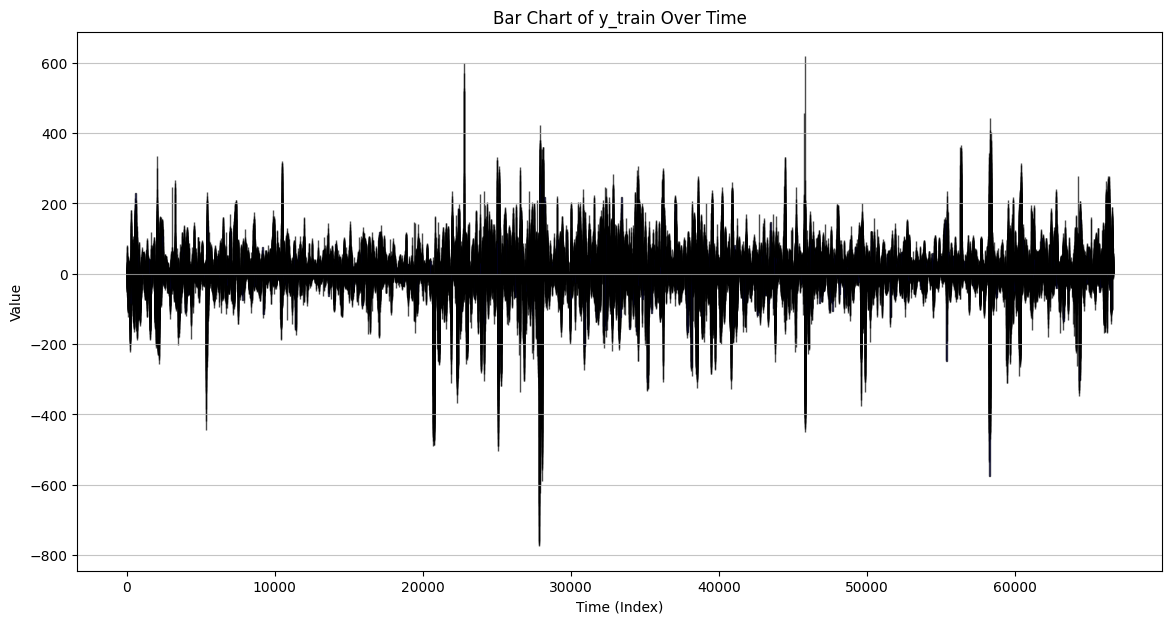

In [ ]:

# Plot bar chart for y_train over time
plt.figure(figsize=(14, 7))
plt.bar(y_train.index, y_train, color='blue', alpha=0.7, edgecolor='black')
plt.title('Bar Chart of y_train Over Time')
plt.xlabel('Time (Index)')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [105]:

X_train

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66619,-0.024626,0.003856,0.001275,72.743590,77.0,4.256410,5.5,0.879556,0.081160,-0.798396,...,0.001522,0.001373,0.000998,-0.001511,-0.001411,-0.001361,-0.001766,-0.001130,-0.001006,-0.000613
66620,-0.023347,0.003647,0.001623,77.923077,76.5,-1.423077,8.5,0.879967,0.083481,-0.796487,...,0.001522,0.001373,0.000998,-0.001173,-0.001411,-0.001292,-0.001763,-0.001130,-0.001006,-0.000613
66621,-0.022155,0.003615,-0.000027,56.000000,61.0,5.000000,1.5,0.880082,0.634037,-0.246045,...,0.002466,0.002313,0.001682,-0.000755,-0.000533,-0.000567,-0.000460,-0.000185,-0.000066,0.000070
66622,-0.022627,0.003602,0.000443,62.205128,73.0,10.794872,2.5,0.880404,0.085893,-0.794511,...,0.001522,0.001373,0.000998,-0.001158,-0.001416,-0.001291,-0.001763,-0.001130,-0.001006,-0.000613


In [106]:
# import numpy as np
# import pandas as pd

# # Check for infinity values in X_train
# print("Checking for infinity values in X_train...")

# # Method 1: Check which rows contain infinity values
# inf_mask = np.isinf(X_train).any(axis=1)
# invalid_rows = X_train[inf_mask]

# print(f"Number of rows with infinity values: {inf_mask.sum()}")
# print(f"Total rows in X_train: {len(X_train)}")
# print(f"Percentage of rows with infinity: {inf_mask.sum() / len(X_train) * 100:.2f}%")

# if len(invalid_rows) > 0:
#     print("\nRows with infinity values:")
#     print(invalid_rows)
    
#     # Show which columns contain infinity values
#     inf_columns = X_train.columns[np.isinf(X_train).any(axis=0)]
#     print(f"\nColumns containing infinity values: {list(inf_columns)}")
    
#     # Count infinity values per column
#     inf_count_per_column = np.isinf(X_train).sum()
#     inf_count_per_column = inf_count_per_column[inf_count_per_column > 0]
#     print("\nInfinity count per column:")
#     for col, count in inf_count_per_column.items():
#         print(f"  {col}: {count}")
    
#     # Show first few rows with infinity for inspection
#     print(f"\nFirst 5 rows with infinity values:")
#     print(invalid_rows.head())
    
# else:
#     print("No infinity values found in X_train.")

# # Method 2: Check for both positive and negative infinity separately
# pos_inf_mask = np.isposinf(X_train).any(axis=1)
# neg_inf_mask = np.isneginf(X_train).any(axis=1)

# print(f"\nRows with positive infinity: {pos_inf_mask.sum()}")
# print(f"Rows with negative infinity: {neg_inf_mask.sum()}")

In [107]:

# # Drop columns with infinity values
# X_train = X_train.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_train.columns}")

In [108]:

# # Drop columns with infinity values
# X_test = X_test.drop(columns=inf_columns)
# print(f"Columns with infinity values have been dropped. Remaining columns: {X_test.columns}")

In [8]:

def model_evaluation(y_true, y_pred, dataset_type="Train",thres = 5,if_plot=True, if_stats=True):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)

    y_true_filtered = []
    for i in range(len(y_true)):
        if y_pred[i] >thres:
            y_true_filtered.append(y_true[i])
        

    
    # 绘制折线图
    if if_plot:
        plt.figure(figsize=(12, 8))
        
        # 主图：均值对比
        plt.subplot(2, 1, 1)
        plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
        plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
        plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                    label=f'Overall True Mean: {overall_true_mean:.4f}')
        plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                    label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
        plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
                label=f'cost baseline: 10')
        
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Mean Value')
        plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 副图：样本数量
        plt.subplot(2, 1, 2)
        plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
        plt.xlabel('Top Percentile Threshold')
        plt.ylabel('Sample Count')
        plt.title('Sample Count by Percentile Threshold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    if if_stats:
        # 输出基本评估指标
        print(f"{dataset_type} Set Evaluation:")
        print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
        print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
        print(f"  R²: {r2:.4f}")
        print(f"  Overall True Mean: {overall_true_mean:.4f}")
        print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
        
        # 输出百分位分析表
        percentile_df = pd.DataFrame({
            'Percentile': percentiles,
            'True_Mean': true_means,
            'Pred_Mean': pred_means,
            'Sample_Count': sample_counts,
            'Mean_Diff': np.array(pred_means) - np.array(true_means)
        })
        
        print(f"{dataset_type} Set Percentile Analysis:")
        print(percentile_df.round(4))
    return len(y_true_filtered), np.mean(y_true_filtered),

    # # return percentile_df

In [11]:
pca = PCA(n_components=0.99)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
shape_before = X_train.shape[1]
shape_after = X_train_pca.shape[1]
print(f"PCA reduced the number of features from {shape_before} to {shape_after}.")

PCA reduced the number of features from 160 to 21.


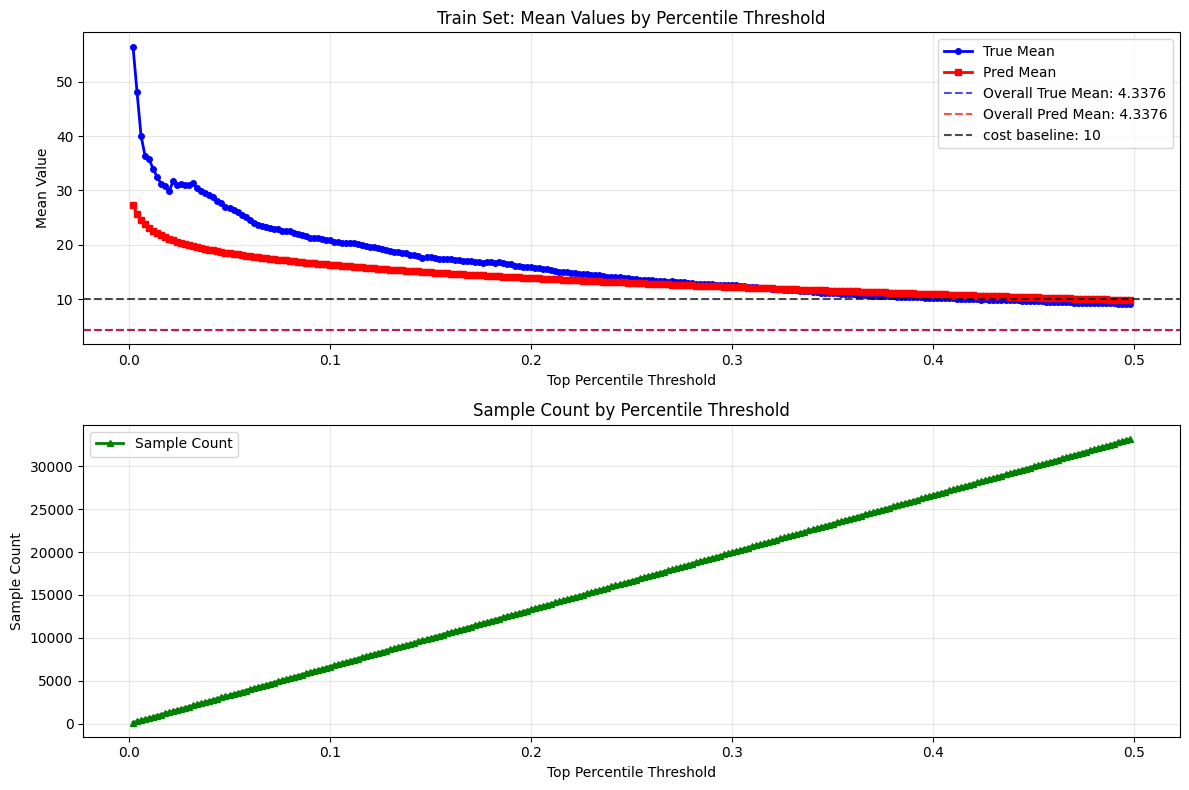

Train Set Evaluation:
  MAE: 46.2216, Relative MAE: 0.6677
  RMSE: 68.8845, Relative RMSE: 0.9951
  R²: 0.0097
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3376

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    56.4590    27.2923           134   -29.1667
1         0.004    48.0642    25.6551           267   -22.4091
2         0.006    40.0388    24.6154           400   -15.4234
3         0.008    36.3540    23.8226           533   -12.5314
4         0.010    35.7180    23.1638           667   -12.5542
..          ...        ...        ...           ...        ...
244       0.490     9.2261     9.9104         32646     0.6843
245       0.492     9.1923     9.8882         32779     0.6960
246       0.494     9.1257     9.8662         32912     0.7405
247       0.496     9.0802     9.8440         33046     0.7638
248       0.498     9.0931     9.8220         33179     0.7288

[249 rows x 5 columns]


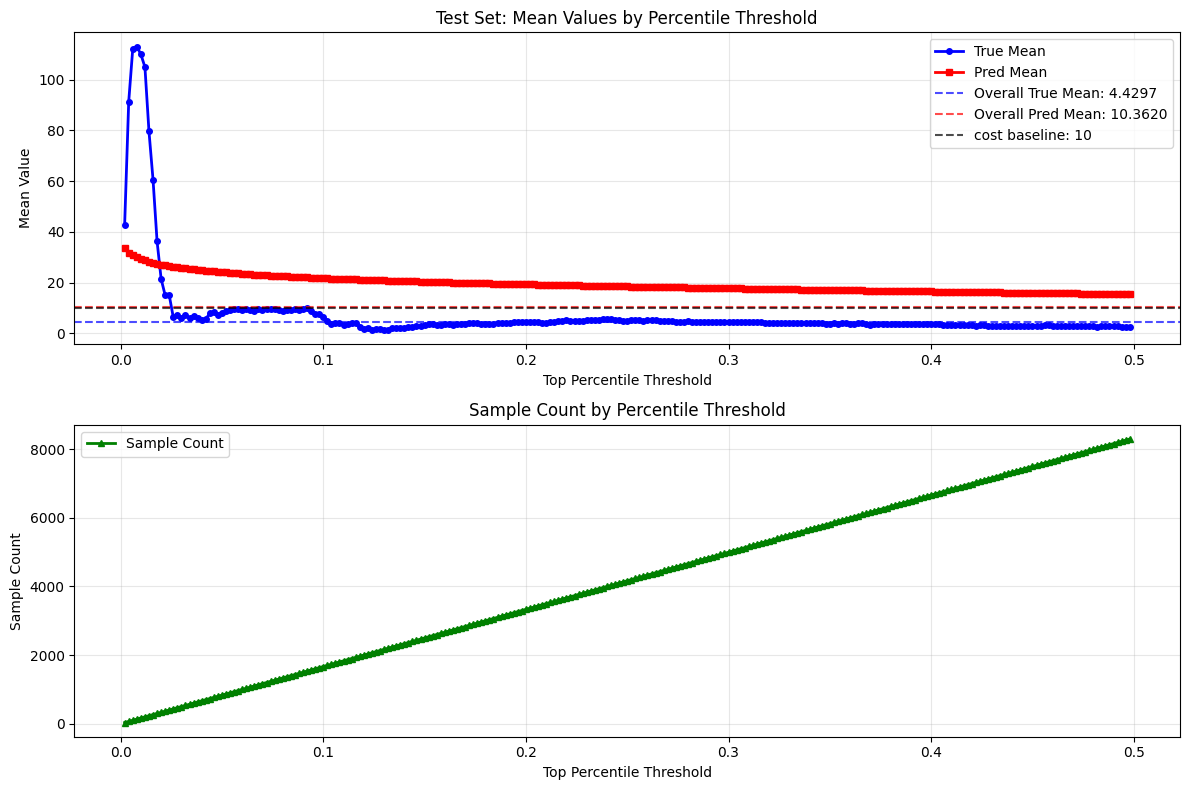

Test Set Evaluation:
  MAE: 56.3229, Relative MAE: 0.4597
  RMSE: 122.8367, Relative RMSE: 1.0025
  R²: -0.0051
  Overall True Mean: 4.4297
  Overall Pred Mean: 10.3620

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    42.8584    33.5566            34    -9.3018
1         0.004    91.2897    31.8160            67   -59.4737
2         0.006   112.1775    30.7316           100   -81.4459
3         0.008   113.0427    29.9382           134   -83.1045
4         0.010   109.9560    29.2876           167   -80.6684
..          ...        ...        ...           ...        ...
244       0.490     2.8157    15.4919          8162    12.6762
245       0.492     2.7881    15.4716          8195    12.6835
246       0.494     2.6481    15.4507          8229    12.8026
247       0.496     2.6441    15.4304          8262    12.7863
248       0.498     2.6418    15.4102          8295    12.7684

[249 rows x 5 columns]


(13289, np.float64(4.062644074677503))

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train_pca, y_train)

y_train_pred = linear_model.predict(X_train_pca)
y_test_pred = linear_model.predict(X_test_pca)
model_evaluation(y_train, y_train_pred, dataset_type="Train",thres=5)
model_evaluation(y_test, y_test_pred, dataset_type="Test",thres=5)

In [13]:

# ===============================
# 2. Ridge Pipeline（标准化 + Ridge）
# ===============================
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(
        alpha=1.0,          # L2 正则强度
        random_state=42
    ))
])

# ===============================
# 3. 训练
# ===============================
ridge_model.fit(X_train, y_train)

# ===============================
# 4. 预测 & 评估
# ===============================
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.6f}")
print(f"Test  MSE: {test_mse:.6f}")

# ===============================
# 5. 系数查看（Ridge 不会稀疏）
# ===============================
coef = ridge_model.named_steps["ridge"].coef_
coef_df = pd.Series(coef, index=X_train.columns).sort_values(key=np.abs, ascending=False)

print("\nTop coefficients by absolute value:")
print(coef_df.head(20))

Train MSE: 4304.506902
Test  MSE: 35602.472649

Top coefficients by absolute value:
residual_mean             172.654481
coef_adj_all              136.550455
coef_adj_selected          53.772493
bb_all_w30720              39.447946
coef_adj_selected_mns     -39.000423
std_all_w7680              23.126510
atr_all_w7680             -21.923825
residual_diff             -20.867499
atr_selected_mns_w60      -18.986697
cmi_all_w7680              17.952169
atr_selected_w60           17.466431
amihud_selected_w7680     -16.380187
std_all_w30720             15.698340
bb_all_w7680              -15.671029
atr_selected_w1920        -15.229019
residual_std              -14.908414
amihud_selected_w30720     14.761264
std_all_w1920             -13.965951
atr_all_w60               -13.215728
atr_all_w480               12.122640
dtype: float64


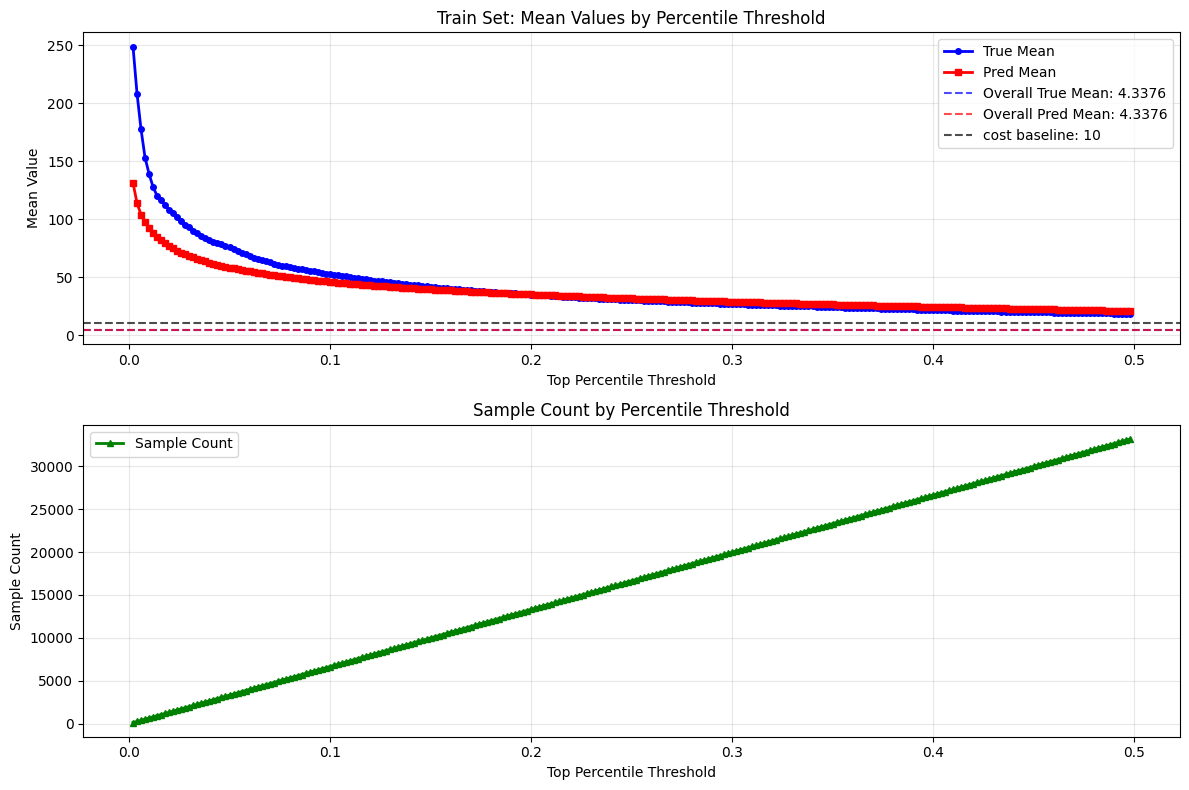

Train Set Evaluation:
  MAE: 45.2413, Relative MAE: 0.6536
  RMSE: 65.6087, Relative RMSE: 0.9478
  R²: 0.1016
  Overall True Mean: 4.3376
  Overall Pred Mean: 4.3376

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   248.7055   131.2319           134  -117.4736
1         0.004   208.0545   113.7247           267   -94.3298
2         0.006   177.2174   103.7697           400   -73.4477
3         0.008   152.7983    97.1565           533   -55.6418
4         0.010   138.9353    92.0884           667   -46.8469
..          ...        ...        ...           ...        ...
244       0.490    18.5457    20.9917         32646     2.4460
245       0.492    18.4829    20.9228         32779     2.4399
246       0.494    18.4240    20.8541         32912     2.4301
247       0.496    18.3683    20.7849         33046     2.4166
248       0.498    18.3198    20.7165         33179     2.3967

[249 rows x 5 columns]


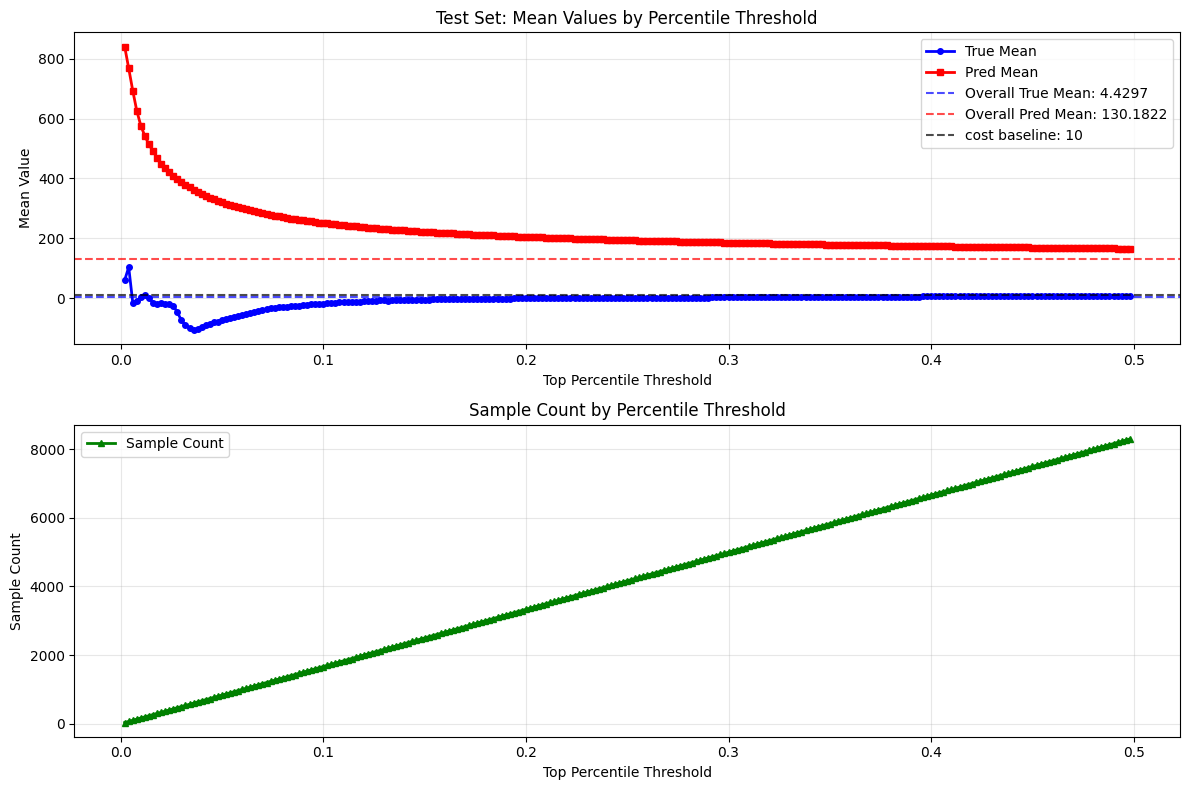

Test Set Evaluation:
  MAE: 134.8628, Relative MAE: 1.1007
  RMSE: 188.6862, Relative RMSE: 1.5399
  R²: -1.3716
  Overall True Mean: 4.4297
  Overall Pred Mean: 130.1822

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    60.4052   840.3835            34   779.9783
1         0.004   103.8452   767.6647            67   663.8195
2         0.006   -14.1496   692.8527           100   707.0022
3         0.008    -8.7442   625.2164           134   633.9606
4         0.010     4.5991   575.9168           167   571.3176
..          ...        ...        ...           ...        ...
244       0.490     6.7700   166.3016          8162   159.5316
245       0.492     6.7714   166.1505          8195   159.3791
246       0.494     6.7858   165.9955          8229   159.2097
247       0.496     6.7918   165.8456          8262   159.0538
248       0.498     6.8407   165.6961          8295   158.8554

[249 rows x 5 columns]


(16625, np.float64(4.392005340408488))

In [14]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [114]:
import numpy as np
import pandas as pd

# Check for infinity values in X_train
print("Checking for infinity values in X_train...")

# Method 1: Check which rows contain infinity values
inf_mask = np.isinf(X_train).any(axis=1)
invalid_rows = X_train[inf_mask]



Checking for infinity values in X_train...


In [115]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge.fit(X_train_80, y_train_80)

val_pred = ridge.predict(X_train_20)
print("Ridge val MSE:", mean_squared_error(y_train_20, val_pred))


Ridge val MSE: 4526.101250196421


In [116]:

# ===============================
# 1. 随机划分 80% / 20%（模拟你原来的 90/10 early stop）
# ===============================
split = int(0.8 * len(X_train))

X_train_80 = X_train.iloc[:split]
y_train_80 = y_train[:split]

X_train_20 = X_train.iloc[split:]
y_train_20 = y_train[split:]

# ===============================
# 2. 定义 LightGBM 回归模型
# ===============================
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mse",
    boosting_type="gbdt",

    n_estimators=8000,
    learning_rate=0.05,

    num_leaves=127,          # 🔥 放开表达能力
    max_depth=-1,

    min_data_in_leaf=30,     # 🔥 关键：从 200 → 30
    min_gain_to_split=0.0,

    subsample=1.0,           # 🔥 先别采样
    subsample_freq=0,
    colsample_bytree=1.0,

    reg_lambda=0.5,          # 轻度 L2，别太狠

    n_jobs=-1,
    random_state=42,
    verbose=-1
)

# ===============================
# 3. 训练（Early Stopping）
# ===============================
print("Training LightGBM with early stopping...")

model.fit(
    X_train_80,
    y_train_80,
    eval_set=[(X_train_20, y_train_20)],
    eval_metric="mse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True)
    ]
)

# ===============================
# 4. 验证集评估
# ===============================
val_pred = model.predict(X_train_20, num_iteration=model.best_iteration_)
val_mse = mean_squared_error(y_train_20, val_pred)

print(f"Validation MSE: {val_mse:.6f}")
print(f"Best iteration: {model.best_iteration_}")

# ===============================
# 5. 全量预测
# ===============================
y_train_pred = model.predict(X_train, num_iteration=model.best_iteration_)
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration_)

# ===============================
# 6. 可选：特征重要性
# ===============================
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)


Training LightGBM with early stopping...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l2: 4436.33
Validation MSE: 4436.330021
Best iteration: 1


In [117]:
importance_df

,Feature,Importance
86,coin_selected_w480,5
156,std_selected_mns_w480,4
40,amihud_all_w30720,4
0,residual_diff,3
85,coin_selected_w120,3
...,...,...
90,coin_selected_mns_w30,0
41,amihud_selected_w30,0
42,amihud_selected_w60,0
87,coin_selected_w1920,0


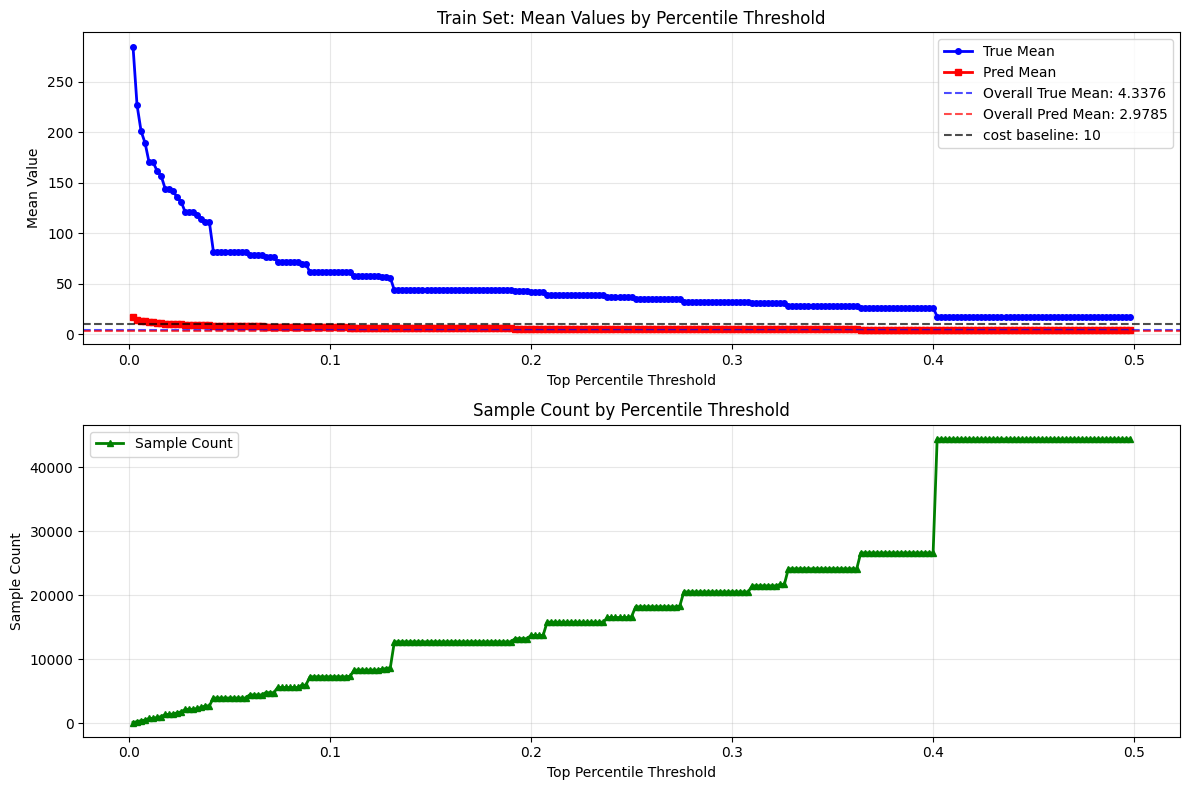

Train Set Evaluation:
  MAE: 45.8295, Relative MAE: 0.6621
  RMSE: 68.0222, Relative RMSE: 0.9827
  R²: 0.0343
  Overall True Mean: 4.3376
  Overall Pred Mean: 2.9785

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   284.7410    16.9809           148  -267.7601
1         0.004   226.8432    14.2018           300  -212.6414
2         0.006   201.0515    13.1623           434  -187.8892
3         0.008   189.2652    12.5437           543  -176.7215
4         0.010   170.0176    11.6626           806  -158.3550
..          ...        ...        ...           ...        ...
244       0.490    17.3877     4.0122         44429   -13.3755
245       0.492    17.3877     4.0122         44429   -13.3755
246       0.494    17.3877     4.0122         44429   -13.3755
247       0.496    17.3877     4.0122         44429   -13.3755
248       0.498    17.3877     4.0122         44429   -13.3755

[249 rows x 5 columns]


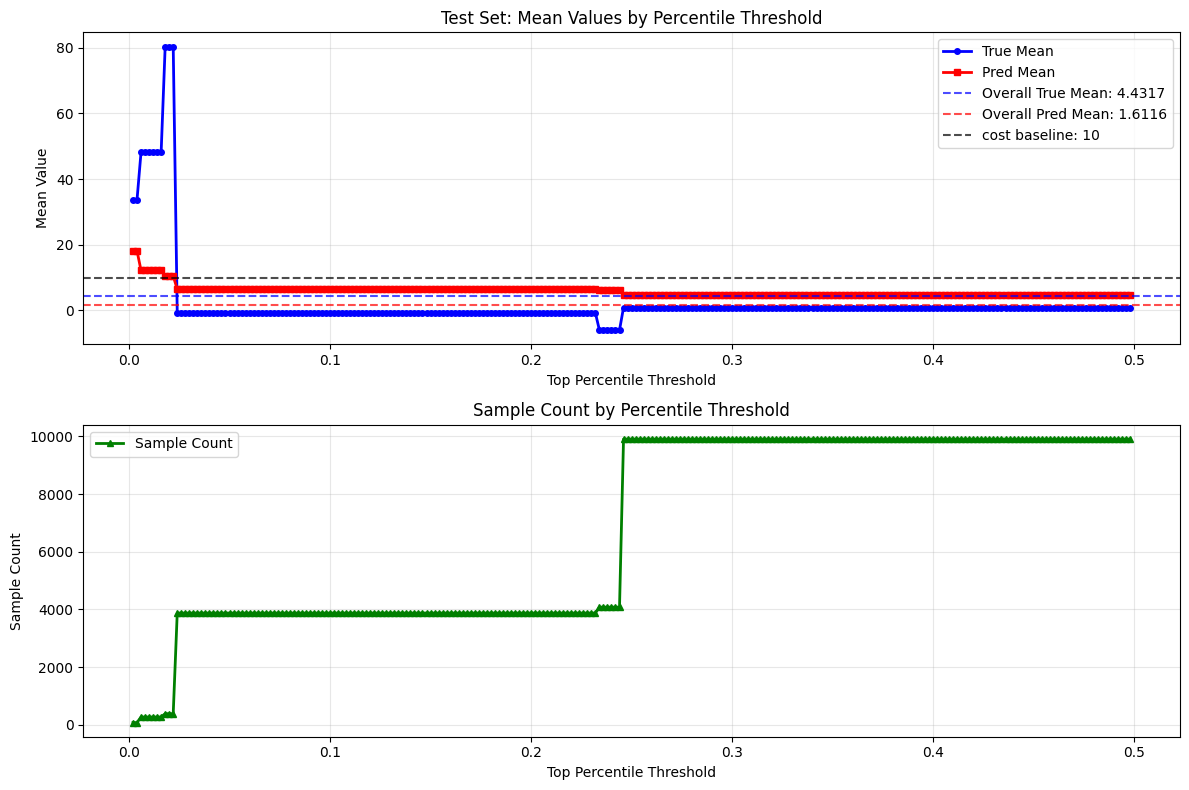

Test Set Evaluation:
  MAE: 56.3776, Relative MAE: 0.4601
  RMSE: 122.7214, Relative RMSE: 1.0016
  R²: -0.0032
  Overall True Mean: 4.4317
  Overall Pred Mean: 1.6116

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    33.7499    18.0787            75   -15.6712
1         0.004    33.7499    18.0787            75   -15.6712
2         0.006    48.2557    12.1469           269   -36.1088
3         0.008    48.2557    12.1469           269   -36.1088
4         0.010    48.2557    12.1469           269   -36.1088
..          ...        ...        ...           ...        ...
244       0.490     0.8629     4.6499          9912     3.7870
245       0.492     0.8629     4.6499          9912     3.7870
246       0.494     0.8629     4.6499          9912     3.7870
247       0.496     0.8629     4.6499          9912     3.7870
248       0.498     0.8629     4.6499          9912     3.7870

[249 rows x 5 columns]


(3876, np.float64(-0.7909229260972525))

In [118]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [28]:
# Resetting the index for X_train and y_train after slicing
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [18]:
# Identify columns where the name contains 'mns' and starts with 'amihud_selected_'
columns_to_zero = [col for col in X_train.columns if 'mns' in col or col.startswith(('coin', 'amihud', 'bb'))]


In [19]:
len(columns_to_zero)

94

,residual_diff,residual_std,residual_mean,residual_z_all,residual_z_selected,residual_z_selected_mns,residual_sign,corr_all,corr_selected,corr_selected_mns,...,std_selected_w1920,std_selected_w7680,std_selected_w30720,std_selected_mns_w30,std_selected_mns_w60,std_selected_mns_w120,std_selected_mns_w480,std_selected_mns_w1920,std_selected_mns_w7680,std_selected_mns_w30720
0,-0.012515,0.002487,-0.005171,14.435897,51.5,37.064103,18.5,0.524132,0.419122,-0.105009,...,0.001286,0.001104,0.001115,0.000392,0.000334,0.000282,0.000230,0.000140,0.000121,0.000132
1,-0.012616,0.002489,-0.004841,18.256410,48.0,29.743590,18.5,0.515330,0.414294,-0.101035,...,0.001286,0.001104,0.001115,0.000402,0.000334,0.000281,0.000230,0.000139,0.000121,0.000132
2,-0.010667,0.002262,-0.004013,24.666667,53.5,28.833333,17.5,0.506414,0.416122,-0.090292,...,0.001286,0.001104,0.001115,0.000403,0.000358,0.000292,0.000233,0.000140,0.000121,0.000132
3,-0.010289,0.002236,-0.004138,24.358974,52.0,27.641026,17.5,0.491788,0.417261,-0.074526,...,0.001286,0.001104,0.001115,0.000417,0.000359,0.000292,0.000232,0.000140,0.000121,0.000132
4,-0.010742,0.002210,-0.003835,25.974359,44.0,18.025641,17.5,0.479400,0.425993,-0.053407,...,0.001422,0.001239,0.001268,0.000154,0.000048,0.000010,0.000019,0.000004,-0.000013,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126725,-0.016796,0.002836,0.003806,109.051282,74.0,-35.051282,16.5,0.810398,0.559283,-0.251115,...,0.000441,0.000467,0.000446,-0.000591,-0.000417,-0.000299,-0.000266,-0.000137,-0.000119,-0.000023
126726,-0.015225,0.002684,0.003738,108.333333,77.5,-30.833333,16.5,0.814196,0.576763,-0.237432,...,0.000441,0.000467,0.000446,-0.000614,-0.000430,-0.000305,-0.000268,-0.000137,-0.000119,-0.000023
126727,-0.015639,0.002712,0.003693,107.410256,61.5,-45.910256,17.5,0.816892,0.580483,-0.236409,...,0.000441,0.000467,0.000446,-0.000604,-0.000428,-0.000303,-0.000267,-0.000137,-0.000119,-0.000023
126728,-0.019761,0.003196,0.004117,110.435897,68.5,-41.935897,17.5,0.819253,0.580368,-0.238885,...,0.000445,0.000468,0.000446,-0.000689,-0.000487,-0.000344,-0.000278,-0.000141,-0.000120,-0.000023


In [21]:
X_train_concat[columns_to_zero] = 0
X_test[columns_to_zero] = 0

# Display the updated DataFrame
X_train['amihud_selected_mns_w30']

0        3.966582e-09
1        3.912954e-09
2        5.923107e-09
3        6.219088e-09
4       -3.745836e-08
             ...     
66619   -8.697639e-09
66620   -1.183240e-08
66621    3.657841e-08
66622   -1.187451e-08
66623   -1.172772e-08
Name: amihud_selected_mns_w30, Length: 66624, dtype: float64

In [7]:
import pickle
model = pickle.load(open('random_forest_model_rct.pkl', 'rb'))

In [47]:
# # Multiply columns in X_train starting with 'amihud' by 10e6
# amihud_columns = [col for col in X_train.columns if col.startswith('amihud')]
# X_train[amihud_columns] *= 10e6

# # Display the updated column to verify
# X_train['amihud_all_w30']

In [23]:
X_train = X_train_concat
y_train = y_train_concat

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=500,
    min_samples_leaf=250,
    
    max_samples=0.8,
    max_features=0.8,
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_index = np.random.permutation(len(X_train))
split = int(1 * len(X_train))

X_train_80 = X_train.iloc[random_index[:split]]
y_train_80 = y_train[random_index[:split]]

X_train_20 = X_train.iloc[random_index[split:]]
y_train_20 = y_train[random_index[split:]]

# # 训练模型
print("Training Random Forest...")
model.fit(X_train_80, y_train_80)

# # 验证集评估
# val_pred = model.predict(X_train_20)
# val_mse = mean_squared_error(y_train_20, val_pred)
# print(f"Validation MSE: {val_mse:.6f}")

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

print("Feature importance:")
for name, importance in zip(feature_names, feature_importance):
    print(f"  {name}: {importance:.4f}")

Training Random Forest...
Feature importance:
  residual_diff: 0.1080
  residual_std: 0.0152
  residual_mean: 0.0008
  residual_z_all: 0.0005
  residual_z_selected: 0.0009
  residual_z_selected_mns: 0.0000
  residual_sign: 0.0006
  corr_all: 0.0062
  corr_selected: 0.0049
  corr_selected_mns: 0.0000
  coef_adj_all: 0.0007
  coef_adj_selected: 0.0050
  coef_adj_selected_mns: 0.0000
  close_ret_all_w30: 0.0003
  close_ret_all_w60: 0.0010
  close_ret_all_w120: 0.0042
  close_ret_all_w480: 0.0072
  close_ret_all_w1920: 0.0490
  close_ret_all_w7680: 0.0194
  close_ret_all_w30720: 0.0145
  close_ret_selected_w30: 0.0004
  close_ret_selected_w60: 0.0053
  close_ret_selected_w120: 0.0071
  close_ret_selected_w480: 0.0107
  close_ret_selected_w1920: 0.0551
  close_ret_selected_w7680: 0.0156
  close_ret_selected_w30720: 0.0087
  close_ret_selected_mns_w30: 0.0000
  close_ret_selected_mns_w60: 0.0000
  close_ret_selected_mns_w120: 0.0000
  close_ret_selected_mns_w480: 0.0000
  close_ret_selected_

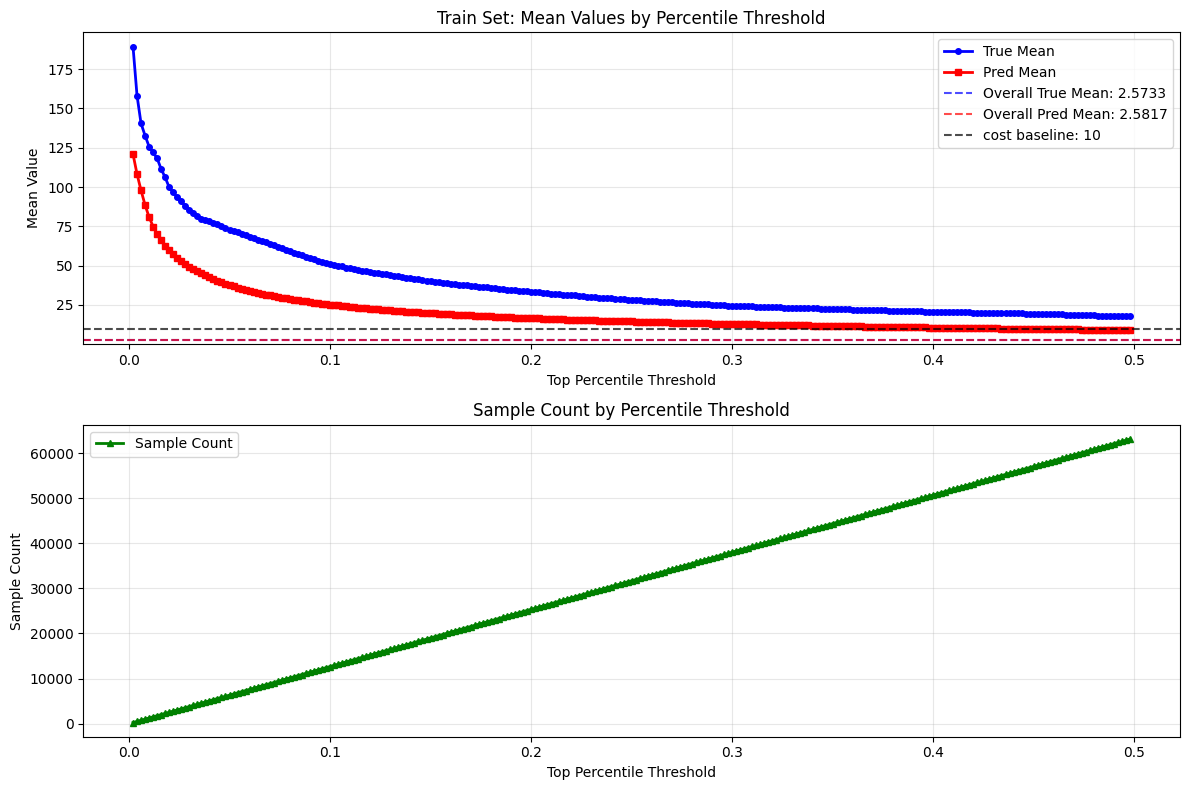

Train Set Evaluation:
  MAE: 38.6589, Relative MAE: 0.6046
  RMSE: 59.4917, Relative RMSE: 0.9305
  R²: 0.1342
  Overall True Mean: 2.5733
  Overall Pred Mean: 2.5817

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002   189.3734   120.9716           254   -68.4018
1         0.004   158.1415   108.2595           507   -49.8820
2         0.006   140.4337    97.8656           761   -42.5681
3         0.008   132.7144    88.5765          1014   -44.1380
4         0.010   125.7581    80.9014          1268   -44.8566
..          ...        ...        ...           ...        ...
244       0.490    18.0193     9.1777         62098    -8.8417
245       0.492    17.9304     9.1504         62351    -8.7800
246       0.494    17.8649     9.1232         62605    -8.7417
247       0.496    17.7704     9.0963         62858    -8.6741
248       0.498    17.7150     9.0693         63114    -8.6457

[249 rows x 5 columns]


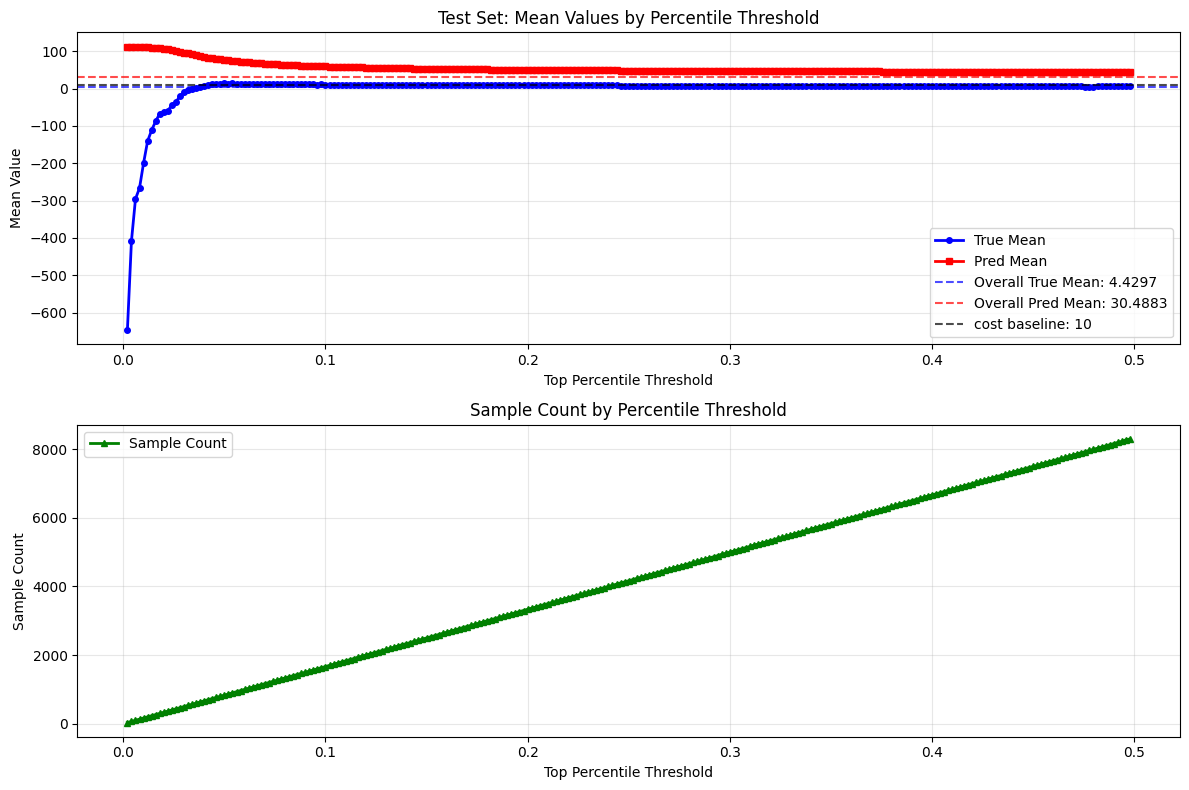

Test Set Evaluation:
  MAE: 63.4041, Relative MAE: 0.5175
  RMSE: 127.4860, Relative RMSE: 1.0405
  R²: -0.0826
  Overall True Mean: 4.4297
  Overall Pred Mean: 30.4883

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002  -646.8795   112.4747            34   759.3542
1         0.004  -408.5586   111.8106            67   520.3691
2         0.006  -295.7269   111.3781           101   407.1050
3         0.008  -266.3611   110.9999           134   377.3610
4         0.010  -199.5725   110.5901           168   310.1627
..          ...        ...        ...           ...        ...
244       0.490     5.4355    43.8646          8162    38.4291
245       0.492     5.4827    43.8285          8195    38.3458
246       0.494     5.5348    43.7910          8229    38.2562
247       0.496     6.1199    43.7452          8270    37.6253
248       0.498     6.2272    43.7170          8295    37.4897

[249 rows x 5 columns]


(15734, np.float64(4.408348099961057))

In [25]:

# 全量预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [26]:
# 特征重要性
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Create a list of (name, importance) pairs and sort by importance (descending)
feature_importance_pairs = list(zip(feature_names, feature_importance))
feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)

print("Feature importance (sorted by importance):")
for name, importance in feature_importance_pairs:
    print(f"  {name}: {importance:.4f}")

# Alternative: Create a DataFrame for easier manipulation
import pandas as pd

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 most important features:")
print(feature_importance_df.head(10).to_string(index=False))

Feature importance (sorted by importance):
  cmi_all_w30720: 0.1205
  residual_diff: 0.1080
  cmi_all_w1920: 0.0670
  close_ret_selected_w1920: 0.0551
  atr_selected_w60: 0.0509
  close_ret_all_w1920: 0.0490
  cmi_all_w7680: 0.0458
  std_all_w7680: 0.0284
  atr_all_w480: 0.0276
  cmi_all_w480: 0.0246
  std_all_w30720: 0.0223
  close_ret_all_w7680: 0.0194
  atr_all_w30720: 0.0166
  std_selected_w60: 0.0164
  close_ret_selected_w7680: 0.0156
  residual_std: 0.0152
  std_all_w120: 0.0148
  atr_all_w7680: 0.0148
  close_ret_all_w30720: 0.0145
  atr_all_w120: 0.0144
  cmi_selected_w30720: 0.0134
  cmi_selected_w480: 0.0129
  std_all_w60: 0.0124
  std_all_w480: 0.0124
  atr_all_w60: 0.0122
  close_ret_selected_w480: 0.0107
  std_all_w30: 0.0106
  atr_all_w1920: 0.0098
  atr_selected_w30: 0.0098
  cmi_selected_w1920: 0.0091
  close_ret_selected_w30720: 0.0087
  cmi_selected_w7680: 0.0074
  atr_selected_w120: 0.0072
  close_ret_all_w480: 0.0072
  close_ret_selected_w120: 0.0071
  std_selected_

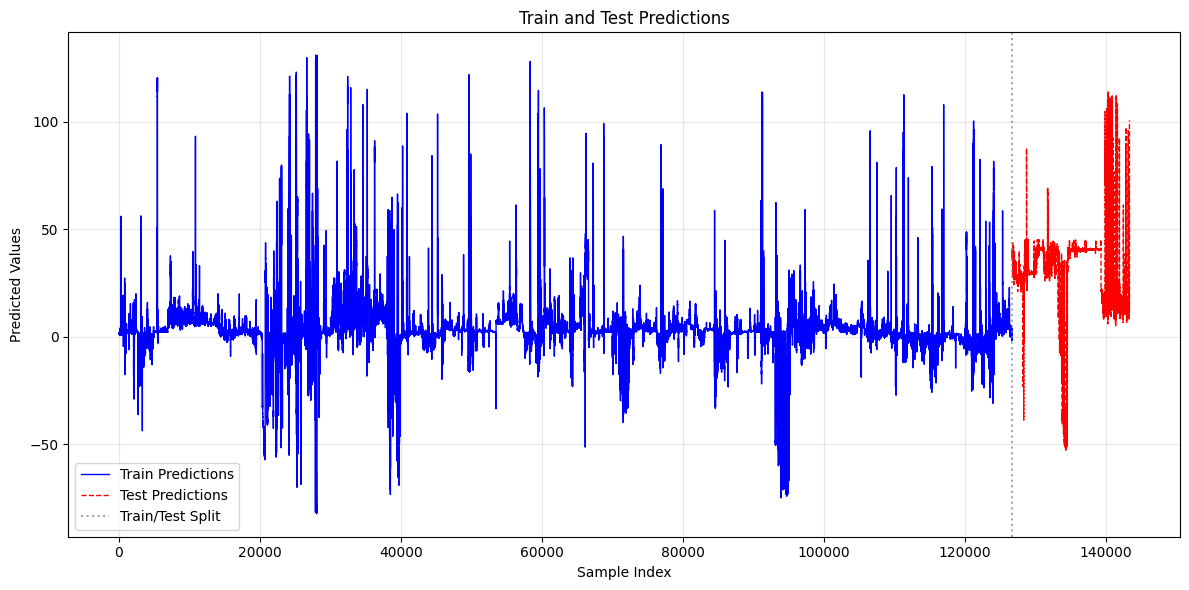

In [27]:
plt.figure(figsize=(12, 6))

# 画训练集预测值（实线）
plt.plot(range(len(y_train_pred)), y_train_pred, 'b-', label='Train Predictions', linewidth=1)

# 画测试集预测值（虚线），从训练集长度开始
plt.plot(range(len(y_train_pred), len(y_train_pred) + len(y_test_pred)), 
         y_test_pred, 'r--', label='Test Predictions', linewidth=1)

# 在连接处画一条分界线
plt.axvline(x=len(y_train_pred), color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

plt.xlabel('Sample Index')
plt.ylabel('Predicted Values')
plt.title('Train and Test Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Calculate the 1000-item moving average
rolling_mean = pd.Series(y_test_pred).rolling(window=1440, min_periods=1).mean()

# Subtract the moving average from y_test_pred
y_test_pred_adjusted = y_test_pred - rolling_mean
len(y_test_pred_adjusted)


16657

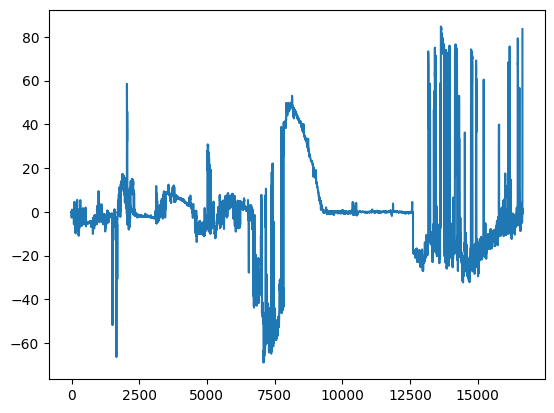

In [29]:
plt.plot(y_test_pred_adjusted)

In [24]:
len(y_test)

16657

Average of non-zero true values (filtered by predicted > 20): 20.75781341566969
Percentage of non-zero true values (filtered by predicted > 20): 11.250525304676714


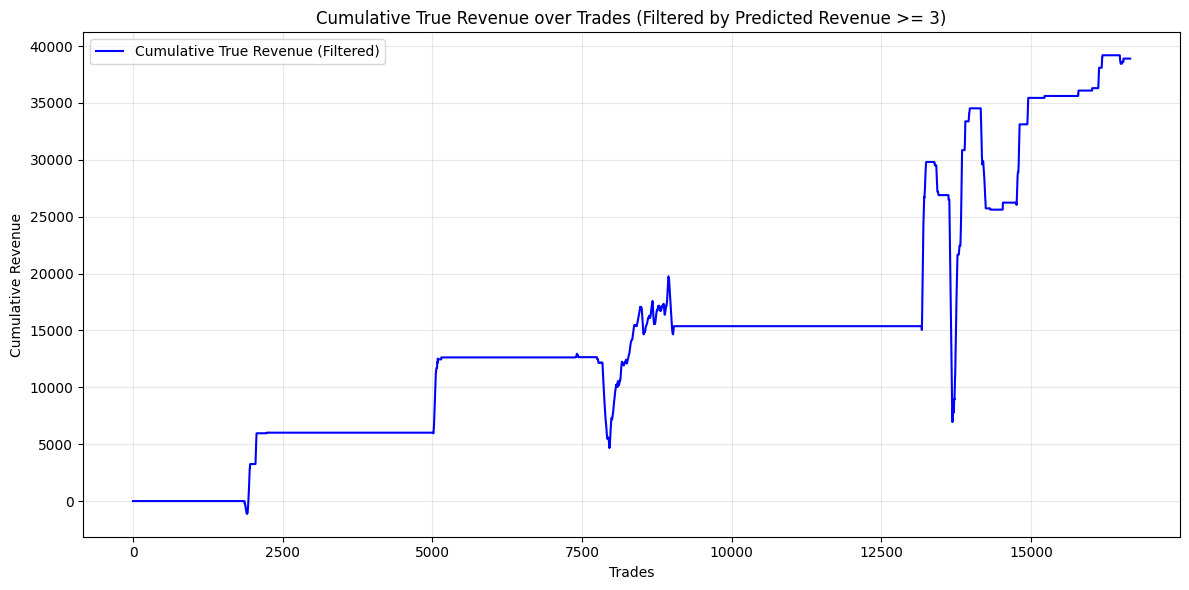

In [31]:
y_true_filtered = []
for i in range(len(y_test)):
    if y_test_pred_adjusted[i] > 15:
        # y_true_filtered.append(y_test[i])
        y_true_filtered.append(min(400,max(-400,y_test[i])))

    else:
        y_true_filtered.append(0)

non_zero_avg = np.mean([val for val in y_true_filtered if val != 0])
non_zero_pct = len([val for val in y_true_filtered if val != 0]) / len(y_true_filtered) * 100
print("Average of non-zero true values (filtered by predicted > 20):", non_zero_avg)
print("Percentage of non-zero true values (filtered by predicted > 20):", non_zero_pct)
y_true_filtered_cumsum = np.cumsum(y_true_filtered)

plt.figure(figsize=(12, 6))
plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
plt.xlabel('Trades')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [28]:
import pickle

# 保存模型
with open('random_forest_model_rct.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as random_forest_model.pkl")

Model saved as random_forest_model.pkl


0        33.605554
1        43.503599
2        42.804372
3        27.200342
4        16.386202
           ...    
16652     0.000000
16653     0.000000
16654     0.000000
16655     0.000000
16656     0.000000
Name: y_test, Length: 16657, dtype: float64